In [1]:
import logging
from trails import Trails, lca, get_lcia_method_names, plot_temporal_scores
from datapackage import Package
from trails.logging import configure_trails_logging, trails_log_context

configure_trails_logging(file_level=logging.DEBUG)

dp = Package("/Users/romain/GitHub/premise/dev/trails_2026-01-25.zip")
trails = Trails(dp, interpolate_annual=True, debug=False)
methods = ["IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)",]

Loading matrices from data package          [1/3]
Loading indices from data package           [2/3]
Interpolating matrices to annual resolution [3/3]


In [2]:
trails.print_exchange_table(year=2050, act_idx=30893, max_rows=50)

flow type    | id           | name                             | reference product                | amount       | td type      | loc          | scale        | min          | max         
-------------+--------------+----------------------------------+----------------------------------+--------------+--------------+--------------+--------------+--------------+-------------
tech         | 30844        | market group for electricity, me | electricity, medium voltage      | -1.03        |              |              |              |              |             
prod         | 30893        | market group for electricity, lo | electricity, low voltage         | 0.97         |              |              |              |              |             
tech         | 12311        | distribution network constructio | distribution network, electricit | -8.74e-08    | 5            | -15.0        |              | -30          | -1          
tech         | 14817        | market for sulfur hexafluoride

In [3]:
from trails.plotting import plot_temporal_graph
plot_temporal_graph(
    trails
)


RuntimeError: Trails graph is missing; run trails.temporal_routing(...) first.

0


Temporal routing: 1node [00:00, 410.68node/s]
Temporal LCA: solve years: 100%|████████████████| 1/1 [00:03<00:00,  3.37s/year]


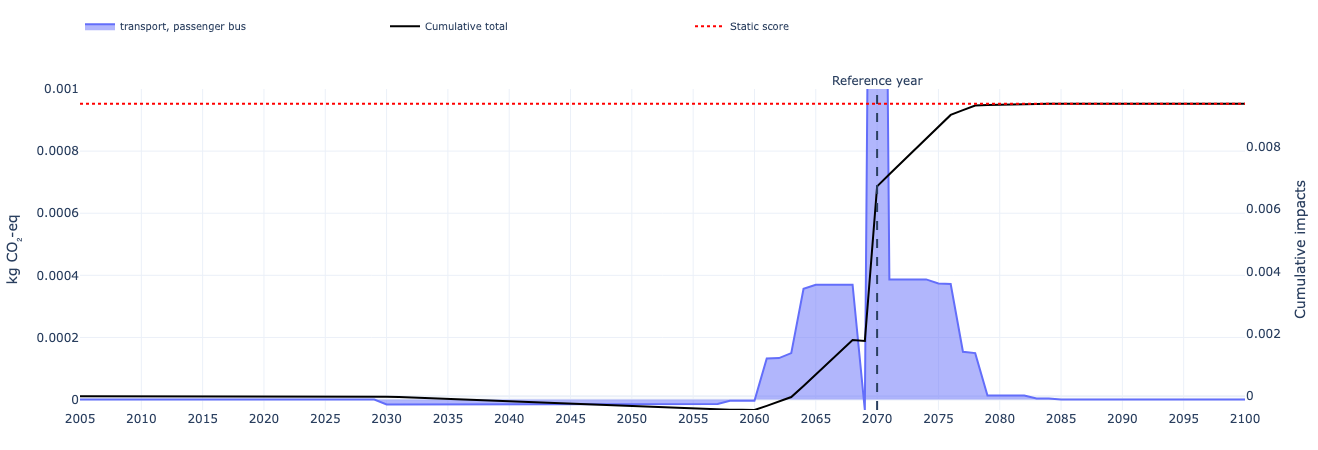

1


Temporal routing: 195node [00:00, 22298.57node/s]
Temporal LCA: solve years: 100%|██████████████| 48/48 [02:40<00:00,  3.35s/year]


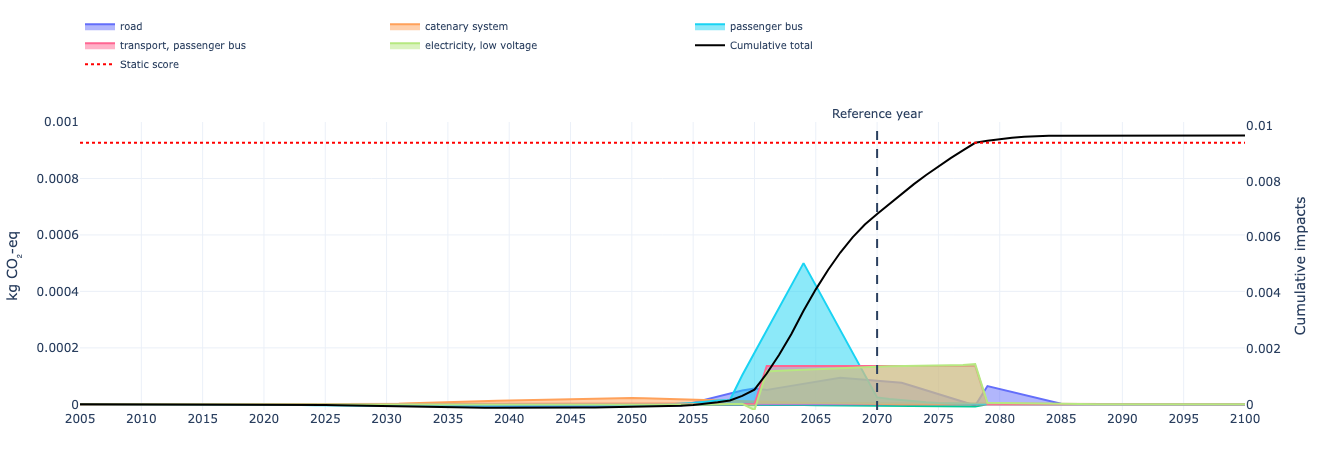

2


Temporal routing: 11377node [00:00, 112131.56node/s]
Temporal LCA: solve years: 100%|██████████████| 76/76 [04:01<00:00,  3.18s/year]


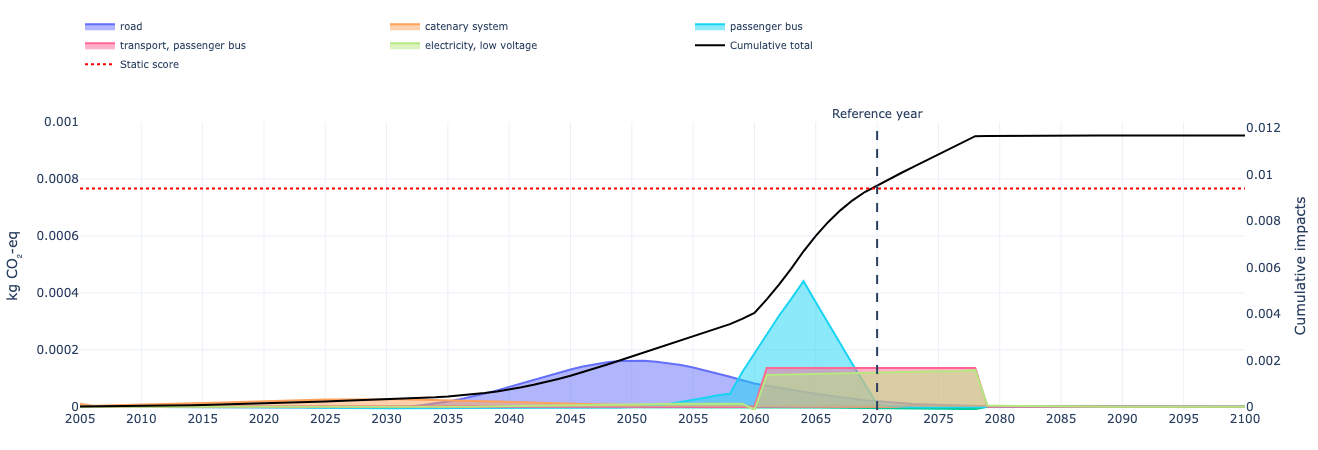

3


Temporal routing: 166826node [00:01, 112789.48node/s]
Temporal LCA: solve years: 100%|██████████████| 96/96 [04:42<00:00,  2.95s/year]


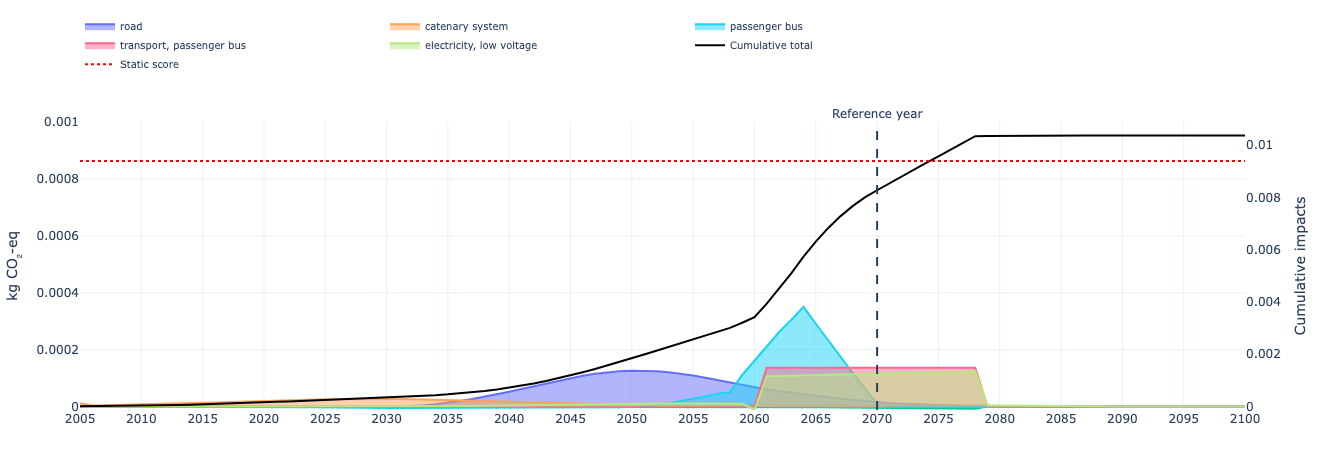

4


Temporal routing: 2446184node [00:18, 132537.40node/s]
Temporal LCA: solve years: 100%|██████████████| 96/96 [04:51<00:00,  3.04s/year]


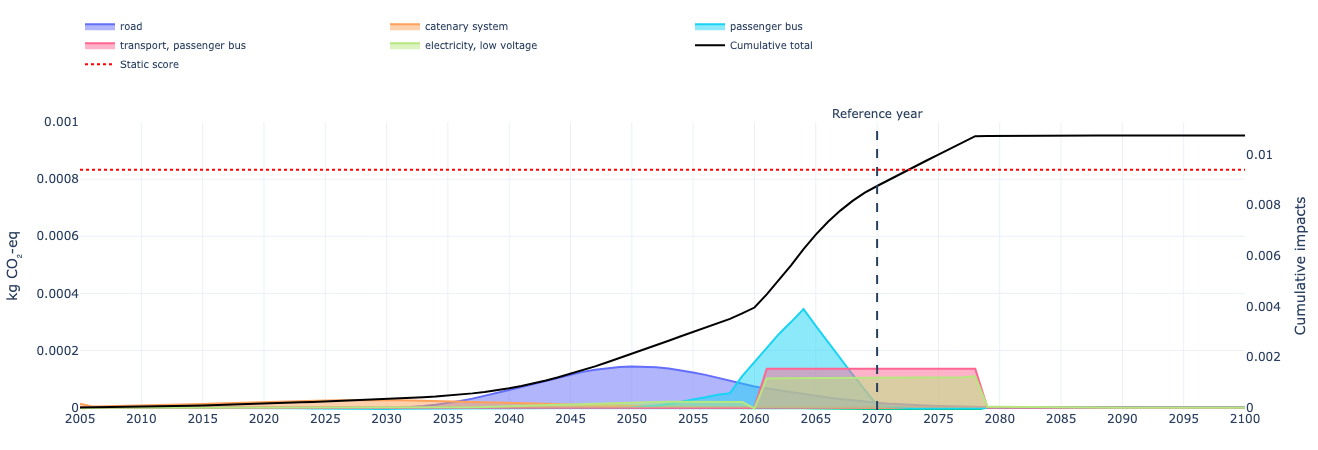

5


Temporal routing: 20370456node [03:19, 101927.54node/s]
Temporal LCA: solve years: 100%|██████████████| 96/96 [05:00<00:00,  3.13s/year]


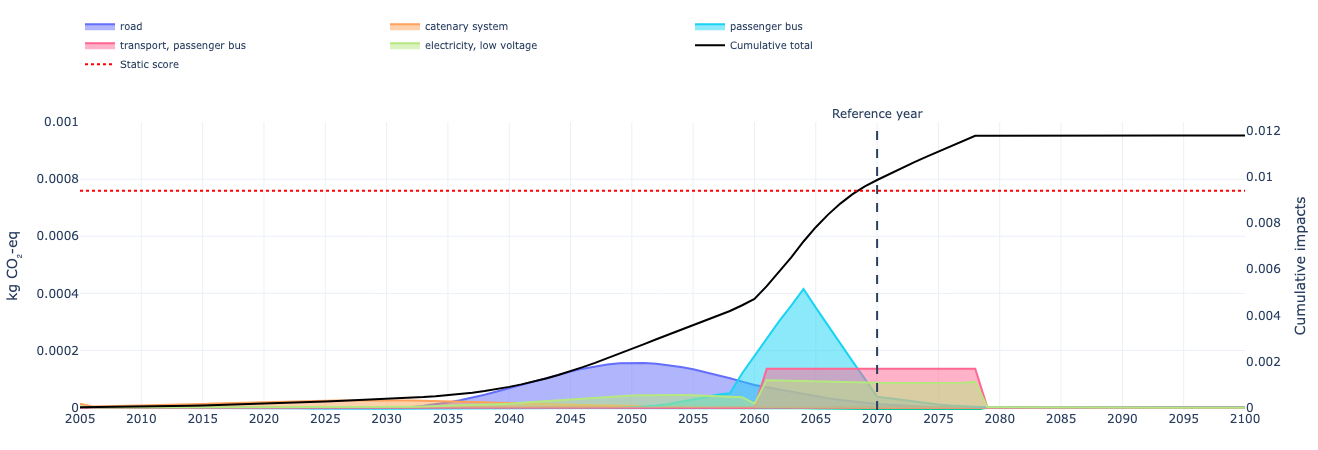

6


Temporal routing: 11488543node [2:08:03, 3641.40node/s] 

In [ ]:
%%time

ref_year = 2070
trails.static_lca(
    year=ref_year,
    act_idx=28673,
    methods=methods,
)

static_score = trails.static_score

for depth in range(0, 9):
    print(depth)

    trails.temporal_routing(
      start_year=ref_year,
      start_act_idx=28673,
      amount=1.0,
      max_depth=depth,
      show_progress=True,
      attribute_to_roots=True,
    )
    
    trails.lca(
        methods=methods,
        show_progress=True,
    )

    fig = plot_temporal_scores(
        results_by_year=trails.scores,
        stacked=False,
        legend_top_n=5,
        show_flow_contributions=False,
        trails=trails,
        title="",
        method_label="kg CO₂-eq",
        cumulative=False,
        width=550,
        height=450,
        year_tick=5,
        #year_range=(2005, 2080),
        reference_year=ref_year,
        show_cumulative_axis=True,
        cumulative_axis_label="Cumulative impacts",
        legend_y=1.15,
        static_score=static_score,
        static_score_dash= "dot",
        static_score_color= "red",
        y_max=0.001,
        #y2_max=0.005
    )
    fig.show()

In [3]:
import numpy as np

yr = 2049

inv = trails.inventory.sum(axis=0).sum(axis=-1)  # flow x year
inv = inv.transpose("flow", "year")

flow_ids = inv.coords["flow"].values
years = inv.coords["year"].values

# get column for the target year
yi = int(np.where(years == yr)[0][0])

vals = np.asarray(inv.data.todense())[:, yi]

label = next(iter(trails.biosphere_indices.keys()))
bio_meta = trails.biosphere_indices[label]

nz = np.where(vals != 0.0)[0]
print("nonzero flows in", yr, ":", len(nz))

for i in nz:
    fid = int(flow_ids[i])
    meta = bio_meta.get(fid, {})
    name = meta.get("name", f"Flow {fid}")
    comp = meta.get("compartment", "")
    sub = meta.get("subcompartment", "")
    unit = meta.get("unit", "")
    if name.startswith("Carbon"):
        print(fid, vals[i], name, comp, sub, unit)

nonzero flows in 2049 : 358
80 1.2389984e-08 Carbon dioxide, fossil air lower stratosphere + upper troposphere kilogram
1018 4.31248e-09 Carbon monoxide, fossil air urban air close to ground kilogram
1778 1.6481473e-09 Carbon monoxide, non-fossil air unspecified kilogram
2278 1.0962298e-05 Carbon dioxide, fossil air non-urban air or from high stacks kilogram
2477 8.925819e-05 Carbon dioxide, non-fossil air unspecified kilogram
3185 1.8908284e-14 Carbon disulfide air non-urban air or from high stacks kilogram
3616 9.806268e-09 Carbon monoxide, fossil air non-urban air or from high stacks kilogram
3722 8.203067e-12 Carbon monoxide, fossil air lower stratosphere + upper troposphere kilogram
5291 0.0005998844 Carbon dioxide, in air natural resource in air kilogram
6188 8.702988e-07 Carbon monoxide, fossil air unspecified kilogram
6505 3.2234611e-06 Carbon dioxide, fossil air urban air close to ground kilogram
7983 0.00015746935 Carbon dioxide, fossil air unspecified kilogram
8120 3.589738e

In [5]:
from trails.characterization import build_characterized_inventory

char = build_characterized_inventory(trails, methods=[methods[0]], char_cache={})

# Sum over flow only (stays sparse)
scores_manual = char.sum(dim="flow")

# Ensure same dim order as trails.scores
if "root activity" in scores_manual.dims:
  scores_manual = scores_manual.transpose("activity", "year", "root activity")
else:
  scores_manual = scores_manual.transpose("activity", "year")

# Example: total score per year (still sparse-aware)
total_by_year = scores_manual.sum(dim=[d for d in scores_manual.dims if d != "year"])
print(total_by_year)

yr = 2049
a = float(scores_manual.sel(year=yr).sum())
b = float(trails.scores.sel(year=yr).sum())
print(a, b)

<xarray.DataArray (year: 96)> Size: 1kB
<COO: shape=(96,), dtype=float64, nnz=65, fill_value=0.0>
Coordinates:
  * year     (year) int64 768B 2005 2006 2007 2008 2009 ... 2097 2098 2099 2100
-0.0001969377142002157 -0.0001969376899069175


In [8]:
yr0 = 2048
yr1 = 2049

inv = trails.inventory.sum(axis=0).sum(axis=-1).transpose("flow", "year")
flow_ids = inv.coords["flow"].values
years = inv.coords["year"].values
i0 = int((years == yr0).nonzero()[0][0])
i1 = int((years == yr1).nonzero()[0][0])

vals0 = inv.isel(year=i0).data
vals1 = inv.isel(year=i1).data

# keep sparse if possible
diff = vals1 - vals0

# get largest movers
if hasattr(diff, "todense"):
  d = np.asarray(diff.todense()).ravel()
else:
  d = np.asarray(diff).ravel()


idx = d.argsort()[::-1]  # biggest increases
idx_neg = d.argsort()    # biggest decreases

label = next(iter(trails.biosphere_indices.keys()))
bio_meta = trails.biosphere_indices[label]

print("Largest increases:")
for i in idx[:20]:
  if d[i] == 0: break
  fid = int(flow_ids[i])
  m = bio_meta.get(fid, {})
  print(fid, d[i], m.get("name"), m.get("compartment"), m.get("subcompartment"))

print("Largest decreases:")
for i in idx_neg[:20]:
  if d[i] == 0: break
  fid = int(flow_ids[i])
  m = bio_meta.get(fid, {})
  print(fid, d[i], m.get("name"), m.get("compartment"), m.get("subcompartment"))

Largest increases:
5291 0.0005853799 Carbon dioxide, in air natural resource in air
Largest decreases:


In [13]:
hits = []
for (label, a, f), tex in trails.temporal_biosphere_exchanges.items():
  if f == 5291:
      hits.append((label, a, tex))
print(hits[:10])

[('2040', 24, TemporalExchange(distribution=4, loc=None, scale=None, offset_min=-1, offset_max=0, amount_source='port')), ('2040', 25, TemporalExchange(distribution=4, loc=None, scale=None, offset_min=-40, offset_max=0, amount_source='port')), ('2040', 54, TemporalExchange(distribution=4, loc=None, scale=None, offset_min=-1, offset_max=0, amount_source='port')), ('2040', 79, TemporalExchange(distribution=4, loc=None, scale=None, offset_min=-1, offset_max=0, amount_source='port')), ('2040', 275, TemporalExchange(distribution=4, loc=None, scale=None, offset_min=-1, offset_max=0, amount_source='port')), ('2040', 324, TemporalExchange(distribution=4, loc=None, scale=None, offset_min=-20, offset_max=0, amount_source='port')), ('2040', 341, TemporalExchange(distribution=4, loc=None, scale=None, offset_min=-40, offset_max=0, amount_source='port')), ('2040', 358, TemporalExchange(distribution=5, loc=-2.5, scale=None, offset_min=-5, offset_max=-1, amount_source='port')), ('2040', 367, TemporalE

In [16]:
import numpy as np

ref_year = 2050
yr = 2049
flow = 5291  # CO2 in air

inv = trails.inventory

# collapse root activity if present
if "root activity" in inv.dims:
  inv_afy = inv.sum(dim="root activity")
else:
  inv_afy = inv

# ensure (activity, flow, year)
inv_afy = inv_afy.transpose("activity", "flow", "year")

# find flow index by coord value
flow_ids = inv_afy.coords["flow"].values
flow_idx = int(np.where(flow_ids == flow)[0][0])

years = inv_afy.coords["year"].values
yi = int(np.where(years == yr)[0][0])

vals = inv_afy.isel(flow=flow_idx).data[:, yi]
if hasattr(vals, "todense"):
  vals = np.asarray(vals.todense()).ravel()
else:
  vals = np.asarray(vals).ravel()

order = np.argsort(vals)  # most negative first
label = next(iter(trails.activity_indices.keys()))
act_meta = trails.activity_indices[label]

top_acts = []
print("Top CO2 uptake contributors at", yr)
for i in order[:20]:
  if vals[i] == 0:
      break
  top_acts.append(int(i))
  meta = act_meta.get(int(i), {})
  print(i, vals[i], meta.get("name"), meta.get("reference product"))

# show TD params for those activities
tpl = str(trails._map_year_to_template_year(ref_year))
print("\nTemporal params:")
for act in top_acts:
  tex = trails.temporal_biosphere_exchanges.get((tpl, act, flow))
  print(act, tex)

Top CO2 uptake contributors at 2049

Temporal params:


In [33]:
import numpy as np
from trails.characterization import get_cf_vector

yr = 2049

# inventory per flow for this year
inv = trails.inventory.sum(axis=0).sum(axis=-1).transpose("flow", "year")
flow_ids = inv.coords["flow"].values
years = inv.coords["year"].values
yi = int(np.where(years == yr)[0][0])
flows = np.asarray(inv.data.todense())[:, yi]

# CF vector
cf = get_cf_vector(trails, methods=[methods[0]], char_cache={})

# per-flow characterized contribution
scores_by_flow = flows * cf

# top absolute contributors
order = np.argsort(np.abs(scores_by_flow))[::-1]

label = next(iter(trails.biosphere_indices.keys()))
bio_meta = trails.biosphere_indices[label]

for i in order[:30]:
  if scores_by_flow[i] == 0:
      break
  fid = int(flow_ids[i])
  meta = bio_meta.get(fid, {})
  print(
      fid,
      scores_by_flow[i],
      meta.get("name", f"Flow {fid}"),
      meta.get("compartment", ""),
      meta.get("subcompartment", ""),
  )

5291 -0.0005998844280838966 Carbon dioxide, in air natural resource in air
7983 0.0001574693451402709 Carbon dioxide, fossil air unspecified
856 0.00013600051133266788 1,1,1,2-Tetrafluoroethane air unspecified
2477 8.925818838179111e-05 Carbon dioxide, non-fossil air unspecified
2278 1.0962297892547213e-05 Carbon dioxide, fossil air non-urban air or from high stacks
6505 3.2234611353487708e-06 Carbon dioxide, fossil air urban air close to ground
9226 2.295488162218362e-06 Dinitrogen monoxide air unspecified
4588 2.2882396830681273e-06 Dinitrogen monoxide air low population density, long-term
7377 6.684789508604183e-07 Dinitrogen monoxide air non-urban air or from high stacks
7099 3.2366423461382967e-07 Methane, fossil air unspecified
5219 2.780293005821832e-07 Dinitrogen monoxide air urban air close to ground
817 6.761011537292917e-08 Methane, fossil air non-urban air or from high stacks
8441 4.8603932753521484e-08 1,1,1,2-Tetrafluoroethane air urban air close to ground
4068 4.16540128

In [ ]:
import numpy as np
import xarray as xr
import sparse
from trails.characterization import build_characterized_inventory

# Ensure characterized inventory is up to date
char = build_characterized_inventory(
  trails=trails,
  methods=[methods[0]],
  char_cache={}
)

# char dims: ("activity","flow","year") or ("activity","flow","year","root activity")
if "root activity" in char.dims:
  # scores dims: (activity, year, root activity)
  scores_manual = char.sum(dim="flow")
  # ensure same dim order as trails.scores
  scores_manual = scores_manual.transpose("activity", "year", "root activity")
else:
  # scores dims: (activity, year)
  scores_manual = char.sum(dim="flow")
  scores_manual = scores_manual.transpose("activity", "year")

# Optional: compare to trails.scores
if trails.scores is not None:
  # For sparse arrays, compare dense if small
  diff = (scores_manual - trails.scores).data
  if hasattr(diff, "todense"):
      diff = np.asarray(diff.todense())
  else:
      diff = np.asarray(diff)
  print("max abs diff:", np.abs(diff).max())

total_by_year = scores_manual.sum(dim=[d for d in scores_manual.dims if d != "year"])
print(total_by_year)

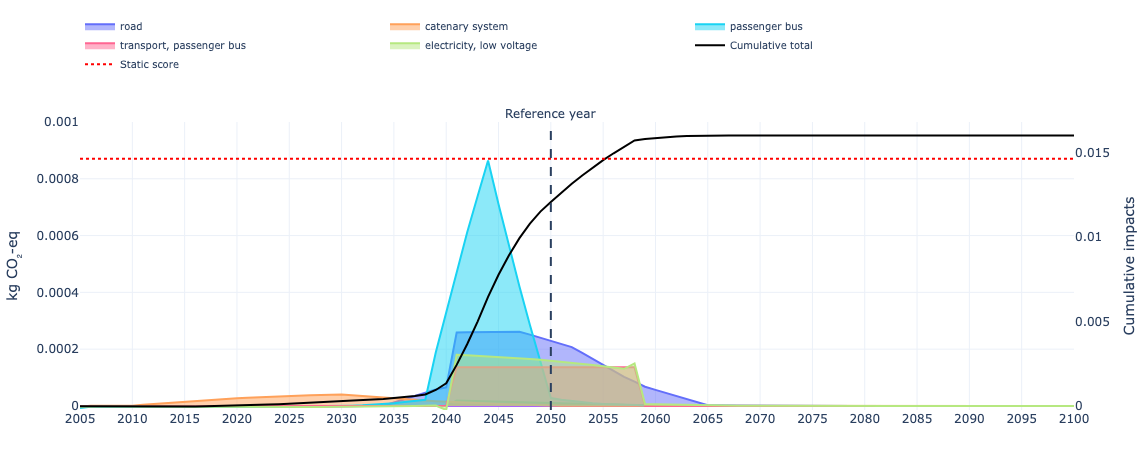

In [5]:
fig = plot_temporal_scores(
    results_by_year=trails.scores,
    stacked=False,
    legend_top_n=5,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    #year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    y_max=0.001,
    #y2_max=0.005
)
fig.show()

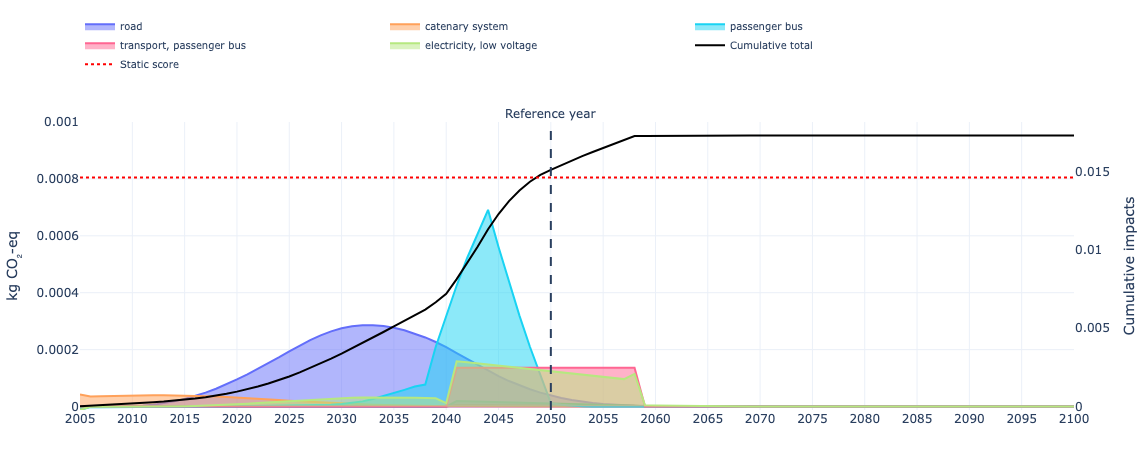

In [8]:
fig = plot_temporal_scores(
    results_by_year=trails.scores,
    stacked=False,
    legend_top_n=5,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    #year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    y_max=0.001,
    #y2_max=0.005
)
fig.show()

In [8]:
trails.scores.sum()

<xarray.DataArray ()> Size: 4B
array(0.01746567, dtype=float32)

In [9]:
%%time

ref_year = 2050

trails.lca(
    start_year=ref_year,
    start_act_idx=36935,
    methods=methods,
    max_depth=2,
    show_progress=True,
    attribute_to_roots=True,
    compute_score=True,
    store_inventory=False,
    debug=True
)



Temporal LCA: solve years: 100%|██████████████| 20/20 [01:04<00:00,  3.25s/year]

CPU times: user 3min 50s, sys: 4.38 s, total: 3min 54s
Wall time: 1min 5s


In [10]:
trails.static_lca(
    year=ref_year,
    act_idx=36935,
    methods=methods,
)

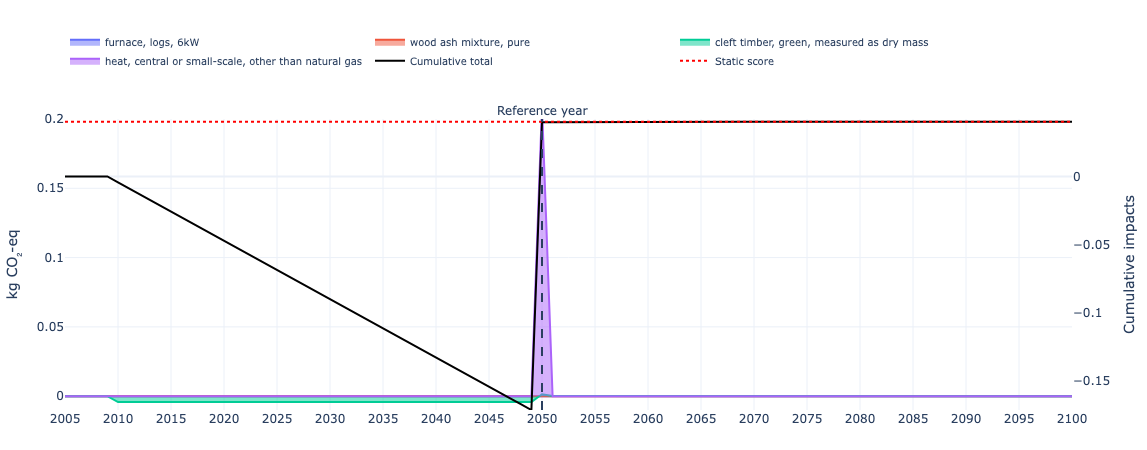

In [11]:
fig = plot_temporal_scores(
    results_by_year=trails.scores,
    stacked=False,
    legend_top_n=5,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    #year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    y_max=0.2,
    y_min=-0.01
    #y2_max=0.005
)
fig.show()

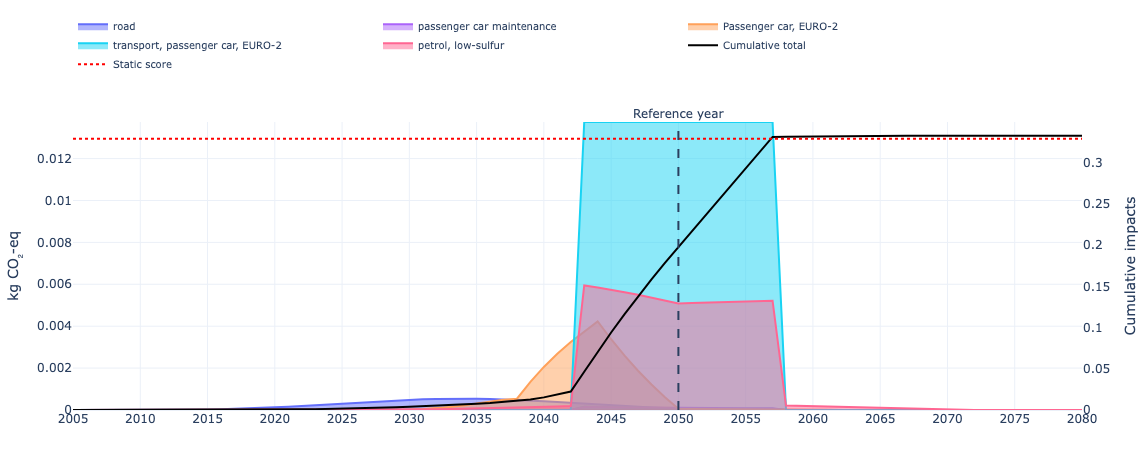

In [4]:
fig = plot_temporal_scores(
    results_by_year=trails.scores,
    stacked=False,
    legend_top_n=5,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()

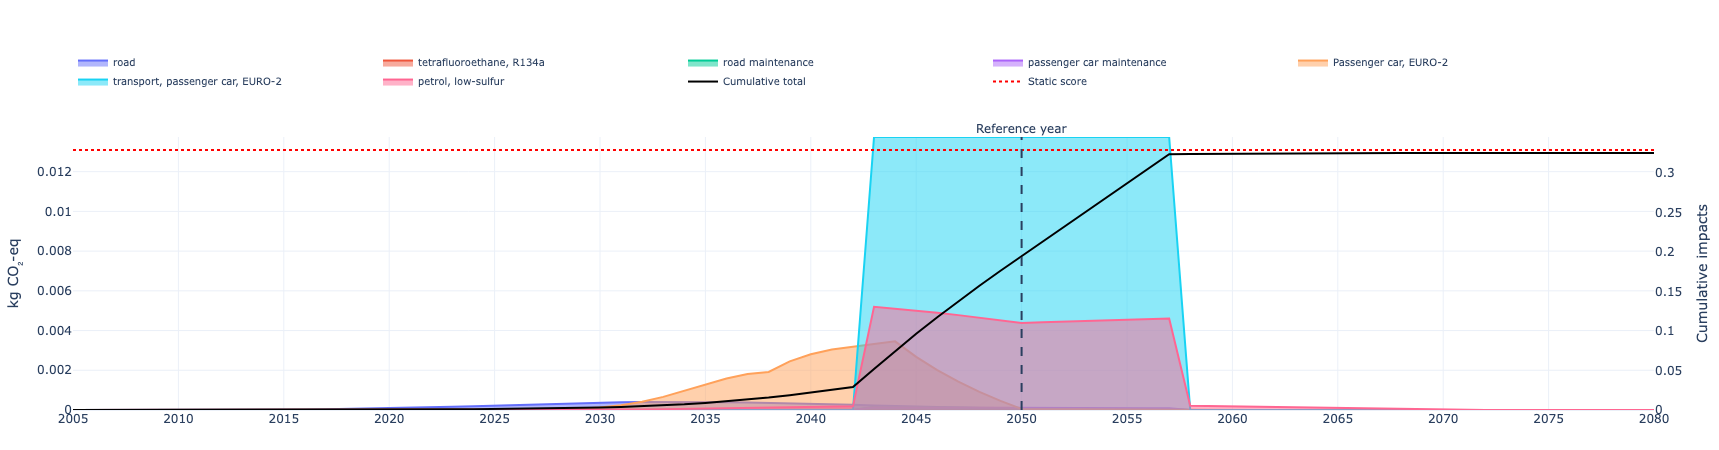

In [4]:
fig = plot_temporal_scores(
    results_by_year=trails.scores,
    stacked=False,
    legend_top_n=10,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()

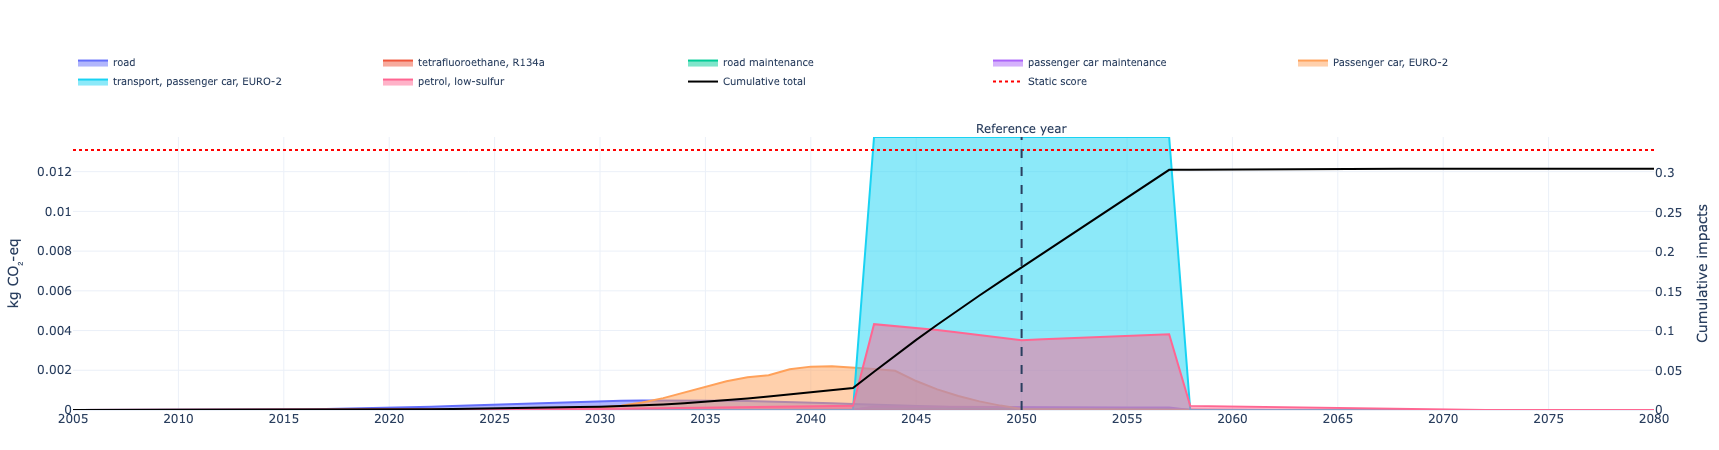

In [5]:
fig = plot_temporal_scores(
    results_by_year=trails.scores,
    stacked=False,
    legend_top_n=10,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()

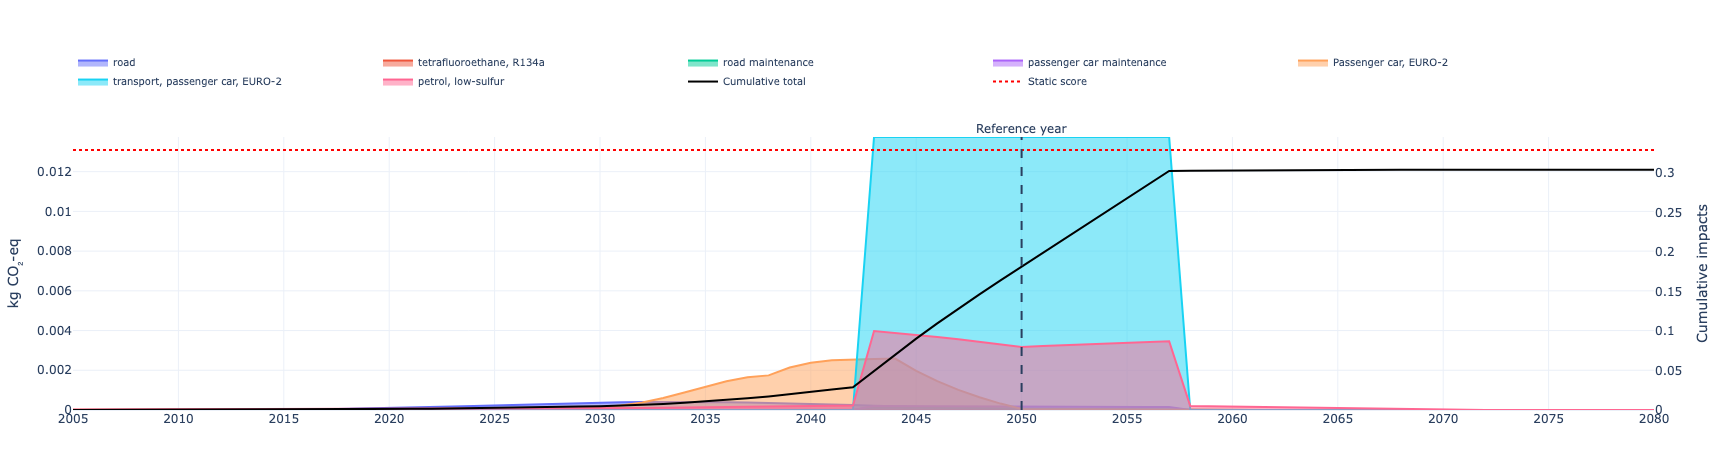

In [4]:
fig = plot_temporal_scores(
    results_by_year=trails.scores,
    stacked=False,
    legend_top_n=10,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()

In [ ]:
fig = plot_temporal_scores(
    results_by_year=trails.scores,
    stacked=False,
    legend_top_n=10,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()